# Decision Trees

            ## 1. Learning objectives

            - Calculate entropy and information gain
- Implement a decision stump
- Diagnose depth-driven overfitting

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Partition feature space with interpretable if-then rules.

            ## 4. Real-world use cases

            - Risk classification
- Demand prediction
- Decision-support ranking

            ## 5. Core intuition in simple language

            Ask the question that most reduces class uncertainty, then repeat inside each resulting group.

## 6. Mathematical foundation

            $$H(Y)=-\sum_{k=1}^{K}p_k\log_2p_k,\qquad IG=H(parent)-\sum_m\frac{n_m}{n}H(child_m).$$

            **Every symbol:**

            - $H$ is entropy.
- $p_k$ is class-k proportion.
- $K$ is class count.
- $IG$ is information gain.
- $m$ indexes children.
- $n_m/n$ weights child size.

            **Why the equation is needed:** Entropy quantifies uncertainty; information gain chooses the split that reduces it most.

            **Small numerical example:** A 50/50 binary node has entropy 1 bit; a pure child has entropy 0.

            **Connection to Python:** The scratch code computes class proportions, weighted child entropy, and selects maximum gain.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

A readable NumPy version exposes the mechanism and is checked against a tiny hand calculation.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def entropy(target):
    _,counts=np.unique(target,return_counts=True)
    probabilities=counts/counts.sum()
    return float(-np.sum(probabilities*np.log2(probabilities+1e-12)))

class DecisionStumpScratch:
    def fit(self,features,target):
        best=(-np.inf,None,None,None,None)
        parent=entropy(target)
        for feature in range(features.shape[1]):
            for threshold in np.unique(features[:,feature]):
                left=features[:,feature]<=threshold
                if left.all() or (~left).all(): continue
                child=(left.mean()*entropy(target[left])+(~left).mean()*entropy(target[~left]))
                gain=parent-child
                left_label=np.bincount(target[left]).argmax(); right_label=np.bincount(target[~left]).argmax()
                if gain>best[0]: best=(gain,feature,threshold,left_label,right_label)
        self.gain_,self.feature_,self.threshold_,self.left_label_,self.right_label_=best
        return self
    def predict(self,features):
        return np.where(features[:,self.feature_]<=self.threshold_,self.left_label_,self.right_label_)

print("Entropy balanced/pure:",round(entropy(np.array([0,0,1,1])),3),round(entropy(np.array([1,1,1])),3))

Entropy balanced/pure: 1.0 -0.0


## 10. Implementation using a standard library

Scikit-learn adds efficient numerical routines, validation, pipelines, and model-selection compatibility.

## 11. Dataset loading and exploration

The lesson uses a bundled or generated scikit-learn dataset with a fixed seed and no network access.

## 12. Data preprocessing

Train/validation/test roles are separated before scaling or other fitted transformations to prevent data leakage.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Stump split: petal length (cm) <= 1.9 gain: 0.918
Stump/tree accuracy: 0.667 0.978


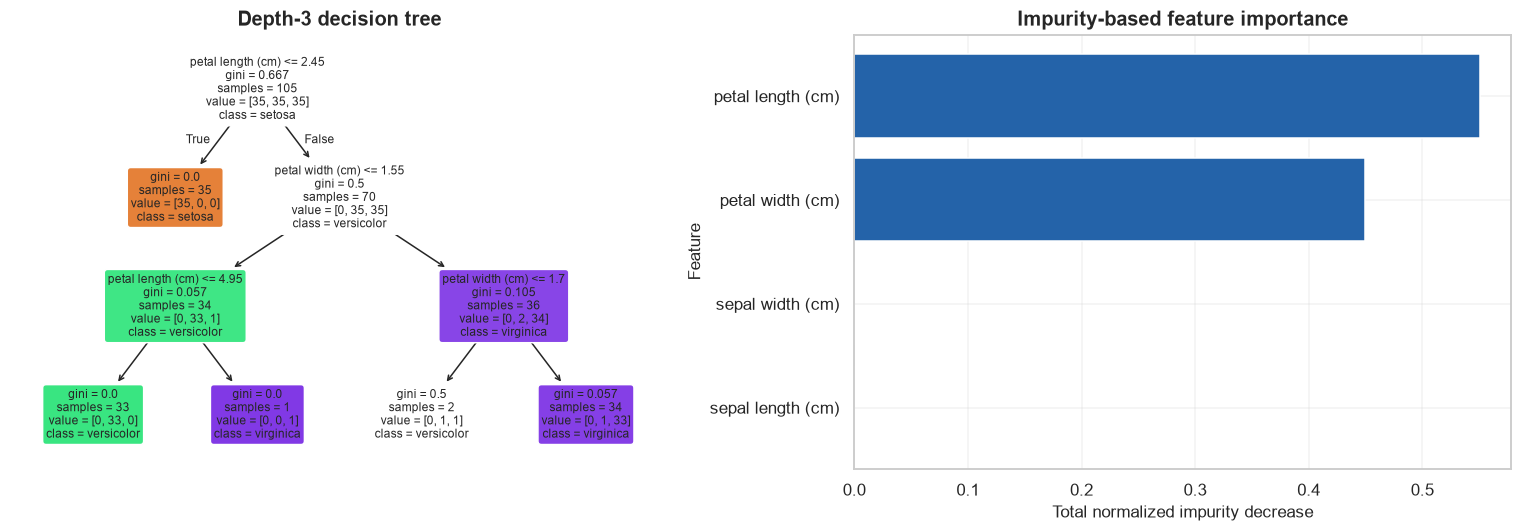

In [3]:
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree

iris=load_iris()
X=iris.data; y=iris.target
X_train,X_validation,y_train,y_validation=train_test_split(X,y,test_size=.3,stratify=y,random_state=RANDOM_SEED)
stump=DecisionStumpScratch().fit(X_train,y_train)
tree=DecisionTreeClassifier(max_depth=3,random_state=RANDOM_SEED).fit(X_train,y_train)
print("Stump split:",iris.feature_names[stump.feature_],"<=",round(stump.threshold_,2),"gain:",round(stump.gain_,3))
print("Stump/tree accuracy:",round(accuracy_score(y_validation,stump.predict(X_validation)),3),round(tree.score(X_validation,y_validation),3))
figure,axes=plt.subplots(1,2,figsize=(14,5))
plot_tree(tree,feature_names=iris.feature_names,class_names=iris.target_names,filled=True,rounded=True,ax=axes[0]); axes[0].set_title("Depth-3 decision tree")
importance=pd.Series(tree.feature_importances_,index=iris.feature_names).sort_values()
axes[1].barh(importance.index,importance.values,color=COURSE_COLORS["blue"]); axes[1].set(title="Impurity-based feature importance",xlabel="Total normalized impurity decrease",ylabel="Feature")
figure.tight_layout(); plt.show()

**How to interpret the result:** The plotted rules are directly readable. Feature importance records impurity reduction, not causal importance.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Depth increases flexibility: training accuracy rises monotonically while validation performance can peak and decline.

,depth,train_accuracy,validation_accuracy
0,1,0.667,0.667
1,2,0.971,0.889
2,3,0.981,0.978
3,4,0.990,0.889
4,5,1.000,0.933
5,6,1.000,0.933
6,7,1.000,0.933
7,8,1.000,0.933
8,9,1.000,0.933
9,10,1.000,0.933


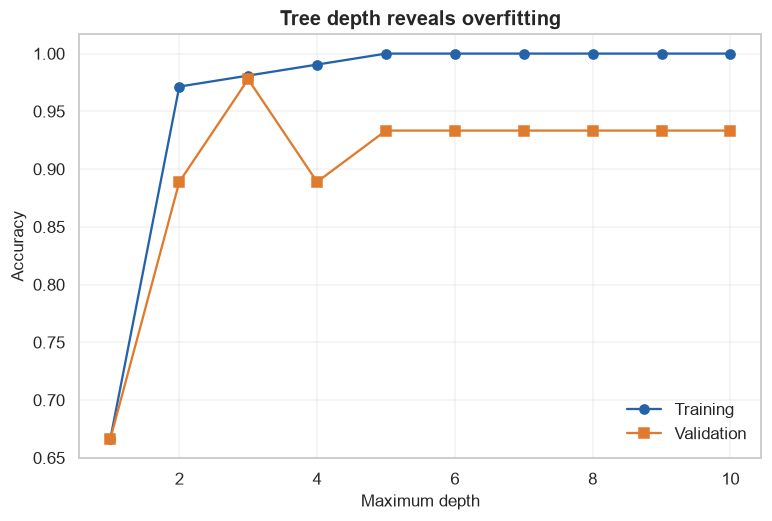

In [4]:
rows=[]
for depth in range(1,11):
    candidate=DecisionTreeClassifier(max_depth=depth,random_state=RANDOM_SEED).fit(X_train,y_train)
    rows.append({"depth":depth,"train_accuracy":candidate.score(X_train,y_train),"validation_accuracy":candidate.score(X_validation,y_validation)})
depth_results=pd.DataFrame(rows); display(depth_results.round(3))
figure,axis=plt.subplots(); axis.plot(depth_results["depth"],depth_results["train_accuracy"],marker="o",label="Training",color=COURSE_COLORS["blue"]); axis.plot(depth_results["depth"],depth_results["validation_accuracy"],marker="s",label="Validation",color=COURSE_COLORS["orange"])
axis.set(title="Tree depth reveals overfitting",xlabel="Maximum depth",ylabel="Accuracy"); axis.legend(); plt.show()

## 18. Common mistakes

            - Fitting preprocessing before splitting
- Selecting hyperparameters on test data
- Reporting one metric without a baseline
- Confusing predictive association with causation

            ## 19. Advantages and disadvantages

            **Advantages**

            - Direct objective from labeled examples
- Clear held-out evaluation

            **Disadvantages**

            - Labels can be costly or biased
- Future data may differ from training data

            ## 20. When to use and when not to use the algorithm

            **Use it when:** a trustworthy target represents the decision and representative labeled examples are available.

            **Do not use it when:** labels do not represent the desired outcome or the goal is causal intervention rather than prediction.

## 21. Exercises

1. **Conceptual:** Why must the test set remain untouched during selection?
2. **Mathematical/hand calculation:** Calculate the displayed equation on a small example.
3. **Coding/experimentation:** Change one hyperparameter and explain training-versus-validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Repeated test feedback leaks selection information and makes final performance optimistic.
2. Substitute each number, compute in the displayed order, and retain units.
3. Keep the split fixed, retrain each candidate, and prefer stable validation evidence rather than the best training score.

</details>

## 23. Summary and key takeaways

            - Data splitting and preprocessing are part of the model
- Scratch code explains the mechanism while the library version supports realistic use
- Metrics must match error costs
- Generalization—not memorization—is the objective

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)